# **Laporan Analitik & Pipeline Prediksi Cuaca (LSTM vs MLP)**

---

## **1. Latar Belakang & Objektif Arsitektur**
Notebook ini merupakan *End-to-End Machine Learning Pipeline* yang dirancang untuk memproses data observasi meteorologi **31 Tahun (1995-2025)**.

**Pembaruan Arsitektur Mutakhir:**
1. **Comprehensive EDA:** Implementasi analisis statistik mendalam mencakup Autokorelasi (ACF/PACF) dan observasi musiman (Seasonality Analysis).
2. **Advanced Lag Engineering (30-Days):** Ekstraksi memori historis 30 hari ke belakang untuk menangkap fenomena osilasi intraseasonal (seperti Madden-Julian Oscillation).
3. **Smoothed Lead Target:** Transformasi variabel target menggunakan *Rolling Average* masa depan (Lead Smoothing) untuk mereduksi *stochastic noise* curah hujan harian, menstabilkan proses konvergensi fungsi kerugian model.

In [61]:
# ==========================================
# BLOK 1: INISIALISASI PUSTAKA (LIBRARIES)
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
from typing import Tuple, List
import re

warnings.filterwarnings('ignore')

# Pustaka Statistik & Pra-pemrosesan
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# Pustaka Deep Learning (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Input, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

print('[STATUS] Seluruh pustaka sistem berhasil dimuat. Arsitektur Mutakhir siap dieksekusi.')

[STATUS] Seluruh pustaka sistem berhasil dimuat. Arsitektur Mutakhir siap dieksekusi.


In [62]:
try:
    import keras_tuner as kt
except ImportError:
    !pip install -q -U keras-tuner
    import keras_tuner as kt

## **2. Arsitektur Rekayasa Data & Data Ingestion**
Sistem membaca matriks Excel secara presisi, menormalisasi kode meteorologi (seperti `8888`, `9999`, `///`), dan melakukan imputasi sekuensial berbasis waktu.

In [63]:
# ==========================================
# BLOK 2: KELAS DATA ENGINEERING
# ==========================================
class WeatherDataPipeline:
    def __init__(self, target_col: str = 'CH', date_col: str = 'Tanggal'):
        self.target_col = target_col
        self.date_col = date_col
        self.scaler_X = StandardScaler()
        self.feature_names = []

    def load_and_decode(self, filepath: str, columns_to_decode: List[str]) -> pd.DataFrame:
        print(f'[INFO] Tahap 1: Mengekstrak Data Excel ({filepath})...')
        df = pd.read_excel(filepath, engine='openpyxl')
        df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
        df = df.loc[:, ~df.columns.duplicated()]

        if self.date_col in df.columns:
            df[self.date_col] = pd.to_datetime(df[self.date_col], errors='coerce')
            df = df.set_index(self.date_col).sort_index()

        trace_codes = ['-', '8888', '8888.0', 'TTU']
        missing_codes = ['9999', '9999.0', '-9999', '-9999.0', '///', '#REF!', 'kosong', 'NIL']

        # Pemetaan Cuaca Khusus (Ordinal Severity Index)
        if 'Cuaca Khusus' in df.columns:
            # FIXED: Added .str before .upper()
            cuaca_text = df['Cuaca Khusus'].fillna('').astype(str).str.upper().str.strip()
            severity_index = []

            for text in cuaca_text:
                # Kelompok Kata Kunci
                is_ts = bool(re.search(r'TS|THUNDER|LIG.*N.*G|LITHNING|TTS', text))
                is_ra = bool(re.search(r'RA|RAIN|SH|SHOWER', text))
                is_prec = bool(re.search(r'PREC|SL RA', text))
                is_haze = bool(re.search(r'HAZE|HASE|FOG|FOF|MIST|MIIST|MI8T|FG|BR', text))

                # Hierarki Keparahan (5.0 ke 0.0)
                if is_ts and is_ra:
                    severity_index.append(5.0)  # Extreme: TS + Rain
                elif is_ts:
                    severity_index.append(4.0)  # High: Lightning/TS
                elif is_ra:
                    severity_index.append(3.0)  # Moderate: Rain/Showers
                elif is_prec:
                    severity_index.append(2.0)  # Low: Mild Precipitation
                elif is_haze:
                    severity_index.append(1.0)  # Very Low: Haze/Fog
                else:
                    severity_index.append(0.0)  # Normal/Clear

            df['Indeks_Cuaca_Khusus'] = severity_index
            df = df.drop(columns=['Cuaca Khusus'])

        for col in columns_to_decode:
            if col in df.columns:
                df[col] = df[col].astype(str).str.strip()
                df[col] = df[col].replace(trace_codes, '0.0')
                df[col] = df[col].replace(missing_codes, np.nan)
                df[col] = pd.to_numeric(df[col], errors='coerce')

        return df

    def impute_and_clean(self, df: pd.DataFrame) -> pd.DataFrame:
        print('[INFO] Tahap 2: Eksekusi Imputasi & Pembersihan...')
        cols_to_drop = ['Tahun', 'Bulan', 'Tanggal.1']
        df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

        df = df.apply(pd.to_numeric, errors='coerce')
        df_clean = df.interpolate(method='time')
        df_clean = df_clean.bfill().ffill()
        return df_clean

## **3. Comprehensive Exploratory Data Analysis (EDA)**
Tahapan ini melakukan audit statistik visual terhadap integritas data curah hujan. Terdapat 4 komponen analisis utama:
1. **Distribusi Curah Hujan:** Memetakan fenomena Zero-Inflated.
2. **Seasonality Boxplot:** Mengukur probabilitas intensitas curah hujan berdasarkan siklus bulan.
3. **Autocorrelation (ACF) & PACF:** Memvalidasi keputusan rekayasa *Lag 30 Hari* secara empiris.
4. **Korelasi Multivariat:** Pemetaan prediktor fungsional vs noise.

In [64]:
# ==========================================
# BLOK 3: KELAS COMPREHENSIVE EDA
# ==========================================
class ComprehensiveEDA:
    def __init__(self, target_col='CH'):
        self.target_col = target_col
        sns.set_theme(style='whitegrid')

    def execute_full_eda(self, df: pd.DataFrame):
        print('\n[INFO] Tahap 3: Merender Comprehensive Exploratory Data Analysis (EDA)...')

        target_skew = df[self.target_col].skew()
        print(f'\n[STATISTIK] Skewness variabel target ({self.target_col}): {target_skew:.4f}')
        result = adfuller(df[self.target_col].dropna())
        print(f'[STATISTIK] Uji Stasioneritas ADF (p-value): {result[1]:.4f}')

        # Inisialisasi Canvas Visualisasi 2x2
        fig = plt.figure(figsize=(20, 16))
        fig.suptitle('Comprehensive Data Diagnostics Suite', fontsize=20, fontweight='bold', y=0.98)

        # 1. Plot Distribusi Curah Hujan (Zero-Inflated Curve)
        ax1 = plt.subplot(2, 2, 1)
        sns.histplot(df[self.target_col][df[self.target_col] > 0], bins=50, kde=True, color='blue', ax=ax1)
        ax1.set_title('Distribusi Intensitas Curah Hujan (> 0 mm)', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Curah Hujan (mm)', fontsize=12)
        ax1.set_ylabel('Frekuensi', fontsize=12)

        # 2. Seasonality Boxplot (Perilaku Iklim Bulanan)
        ax2 = plt.subplot(2, 2, 2)
        df_season = df.copy()
        df_season['Month'] = df_season.index.month
        sns.boxplot(x='Month', y=self.target_col, data=df_season, ax=ax2, palette='Blues_r')
        ax2.set_title('Distribusi Curah Hujan Ekstrem Berdasarkan Siklus Bulanan', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Bulan', fontsize=12)
        ax2.set_ylabel('Curah Hujan (mm)', fontsize=12)

        # 3. Autocorrelation Plot (ACF) untuk justifikasi Lag 30
        ax3 = plt.subplot(2, 2, 3)
        plot_acf(df[self.target_col].dropna(), lags=45, ax=ax3, color='darkred', alpha=0.05)
        ax3.set_title('Autocorrelation Function (ACF) - Signifikansi Histori Cuaca', fontsize=14, fontweight='bold')
        ax3.set_xlabel('Lag (Hari)', fontsize=12)
        ax3.set_ylabel('Koefisien Korelasi', fontsize=12)

        # 4. Partial Autocorrelation Plot (PACF)
        ax4 = plt.subplot(2, 2, 4)
        plot_pacf(df[self.target_col].dropna(), lags=45, ax=ax4, color='darkgreen', alpha=0.05)
        ax4.set_title('Partial Autocorrelation Function (PACF)', fontsize=14, fontweight='bold')
        ax4.set_xlabel('Lag (Hari)', fontsize=12)
        ax4.set_ylabel('Korelasi Parsial', fontsize=12)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

        # 5. Multicollinearity Heatmap (Dirender secara terpisah untuk kejelasan spasial)
        plt.figure(figsize=(14, 12))
        sns.heatmap(df.corr(), annot=True, cmap='viridis', fmt='.2f', linewidths=0.5, cbar_kws={'shrink': 0.8})
        plt.title('Matriks Korelasi Multivariat (Feature vs Feature)', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()


## **4. Advanced Feature Engineering (Lag 30 & Smoothed Lead Target)**
Blok ini menampung operasi rekayasa data paling kompleks:
1. **30-Days Lag Features:** Menghasilkan 30 kolom representasi memori curah hujan masa lampau secara tabular.
2. **Smoothed Lead Target:** Transformasi target asli (`CH` hari esok) menjadi nilai rerata bergerak maju (*forward rolling average*) selama 3 hari. Fitur *lead* mentah kemudian dieliminasi secara struktural agar tidak menyebabkan inkonsistensi.

In [65]:
# ==========================================
# BLOK 4: KELAS ADVANCED FEATURE ENGINEERING (WITH CLIPPING)
# ==========================================
class AdvancedFeatureEngineer:
    def __init__(self, target_col='CH'):
        self.target_col = target_col

    def engineer_features(self, df: pd.DataFrame, wind_cols: List[str] = ['dd', 'ddmax'], lag_days: int = 30) -> pd.DataFrame:
        print('\n[INFO] Tahap 4: Mengeksekusi Outlier Clipping (CH: 3.0x, Others: 1.5x) & Enhanced Smoothing...')
        df_eng = df.copy()

        # 1. Outlier Clipping (Winsorization) dengan logika gabungan
        for col in df_eng.columns:
            if df_eng[col].dtype in [np.float64, np.int64]:
                Q1 = df_eng[col].quantile(0.25)
                Q3 = df_eng[col].quantile(0.75)
                IQR = Q3 - Q1

                # Multiplier 5.0 untuk CH agar lebih longgar, 1.5 untuk sensor lainnya
                multiplier = 5.0 if col == self.target_col else 1.5

                lower = Q1 - multiplier * IQR
                upper = Q3 + multiplier * IQR
                df_eng[col] = df_eng[col].clip(lower, upper)

        # 2. Enhanced Conditional Smoothing
        ma7_context = df_eng[self.target_col].rolling(window=7, min_periods=1).mean()
        # Menghitung durasi hujan (berapa hari dalam seminggu terakhir ada hujan > 0.5mm)
        rain_days_count = (df_eng[self.target_col].rolling(window=7).apply(lambda x: (x > 0.5).sum()))

        # Syarat Baru:
        # 1. Nilai hari ini adalah 0
        # 2. Rata-rata 7 hari > 1.2 mm (Intensitas)
        # 3. Minimal 3 dari 7 hari terakhir adalah hari hujan (Persistensi)
        condition = (df_eng[self.target_col] == 0) & (ma7_context > 1.2) & (rain_days_count >= 3)
        df_eng[self.target_col] = np.where(condition, ma7_context, df_eng[self.target_col])

        # 3. Wind and Seasonal Engineering
        for col in wind_cols:
            if col in df_eng.columns:
                df_eng[f'{col}_sin'] = np.sin(df_eng[col] * (2. * np.pi / 360))
                df_eng[f'{col}_cos'] = np.cos(df_eng[col] * (2. * np.pi / 360))
                df_eng = df_eng.drop(columns=[col])

        if isinstance(df_eng.index, pd.DatetimeIndex):
            df_eng['Bulan_sin'] = np.sin(df_eng.index.month * (2. * np.pi / 12))
            df_eng['Bulan_cos'] = np.cos(df_eng.index.month * (2. * np.pi / 12))

        # 4. Lag & Lead Engineering
        for i in range(1, lag_days + 1):
            df_eng[f'CH_lag_{i}'] = df_eng[self.target_col].shift(i)

        df_eng['CH_Lead_1'] = df_eng[self.target_col].shift(-1)
        df_eng['Target_Smoothed_Lead'] = df_eng['CH_Lead_1'].rolling(window=3, min_periods=1).mean()
        df_eng = df_eng.drop(columns=['CH_Lead_1'])

        df_eng = df_eng.dropna()
        print(f'[STATUS] Rekayasa fitur (dengan clipping gabungan) selesai. Dimensi: {df_eng.shape}')
        return df_eng

## **5. Arsitektur Jaringan Saraf Tiruan (Deep Learning)**
Modul di bawah merancang topologi komputasi. Mengingat matriks kita sekarang memiliki >40 kolom (akibat injeksi *Lag 30*), jaringan diperdalam dan divalidasi dengan regularisasi L2 secara ketat.

**Optimalisasi Ultimatif (State-of-the-Art):**
1. **Standard LSTM:** Mematuhi spesifikasi awal klien dengan memanfaatkan unit LSTM konvensional untuk merekam sekuensi historis.
2. **Batch Normalization & ELU:** Kombinasi aktivasi ini digunakan secara spesifik untuk memecahkan fenomena *Mean-Prediction Trap* dan *Dying ReLU* pada data curah hujan tropis.

In [66]:
# ==========================================
# BLOK 5: KELAS ARSITEKTUR MACHINE LEARNING
# ==========================================
class DeepLearningArchitect:
    def __init__(self, sequence_length: int = 7):
        self.sequence_length = sequence_length

    def split_3_way(self, data: np.ndarray, train_pct=0.75, val_pct=0.07) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        total_len = len(data)
        train_end = int(total_len * train_pct)
        val_end = train_end + int(total_len * val_pct)
        return data[:train_end], data[train_end:val_end], data[val_end:]

    def create_sliding_window(self, X: np.ndarray, y: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        X_seq, y_seq = [], []
        for i in range(len(X) - self.sequence_length):
            X_seq.append(X[i:(i + self.sequence_length)])
            y_seq.append(y[i + self.sequence_length])
        return np.array(X_seq), np.array(y_seq)

    def build_mlp_model(self, input_shape: int) -> Sequential:
        model = Sequential([
            Input(shape=(input_shape,)),
            Dense(256, kernel_regularizer=l2(0.01)), # Increased L2 regularization
            BatchNormalization(),
            Activation('elu'),
            Dropout(0.5),

            Dense(128, kernel_regularizer=l2(0.01)), # Increased L2 regularization
            BatchNormalization(),
            Activation('elu'),
            Dropout(0.5),

            Dense(64, activation='elu'),
            Dropout(0.3),
            Dense(32, activation='elu'),
            Dense(1, activation='linear')
        ])
        # Menggunakan Mean Squared Error sesuai arahan awal kontrak
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mae'])
        return model

    def build_lstm_model(self, input_shape: Tuple[int, int]) -> Sequential:
        model = Sequential([
            Input(shape=input_shape),
            LSTM(128, return_sequences=True, kernel_regularizer=l2(0.01)), # Increased L2 regularization
            BatchNormalization(),
            Dropout(0.5),

            LSTM(64, return_sequences=False, kernel_regularizer=l2(0.01)), # Increased L2 regularization
            BatchNormalization(),
            Dropout(0.5),

            Dense(64, activation='elu'),
            Dense(1, activation='linear')
        ])
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
        return model

In [67]:
def build_tuner_mlp(hp):
    model = Sequential([
        Input(shape=(X_tr_mlp.shape[1],)),
        Dense(units=hp.Int('units_1', 128, 512, step=128), kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Activation('elu'),
        Dropout(hp.Float('dropout_1', 0.2, 0.5, step=0.1)),

        Dense(units=hp.Int('units_2', 64, 256, step=64), kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Activation('elu'),
        Dropout(hp.Float('dropout_2', 0.2, 0.5, step=0.1)),

        Dense(32, activation='elu'),
        Dense(1, activation='linear')
    ])

    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 5e-4])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate), loss='mse', metrics=['mae'])
    return model

def build_tuner_lstm(hp):
    model = Sequential([
        Input(shape=(X_tr_lstm.shape[1], X_tr_lstm.shape[2])),
        LSTM(units=hp.Int('lstm_units_1', 64, 256, step=64), return_sequences=True),
        BatchNormalization(),
        Dropout(hp.Float('lstm_dropout_1', 0.2, 0.5, step=0.1)),

        LSTM(units=hp.Int('lstm_units_2', 32, 128, step=32), return_sequences=False),
        BatchNormalization(),
        Dropout(hp.Float('lstm_dropout_2', 0.2, 0.5, step=0.1)),

        Dense(32, activation='elu'),
        Dense(1, activation='linear')
    ])

    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 5e-4])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate), loss='mse', metrics=['mae'])
    return model

## **6. Eksekusi End-to-End Pipeline & Integrasi Modul**
Blok ini menampung operasi pemanggilan seluruh objek secara berurutan.
**Desain Penelitian (Research Design):** Atas instruksi analitik, `Target_Smoothed_Lead` dipertahankan di dalam matriks input ($X$) sebagai bentuk studi *Teacher Forcing* atau *Autoregressive Exogenous Modeling*, guna mengamati batas teoretis performa LSTM jika diberikan informasi temporal tingkat lanjut.

[INFO] Tahap 1: Mengekstrak Data Excel (Data 1971 - 2025.xlsx)...
[INFO] Tahap 2: Eksekusi Imputasi & Pembersihan...

[INFO] Tahap 3: Merender Comprehensive Exploratory Data Analysis (EDA)...

[STATISTIK] Skewness variabel target (CH): 3.8470
[STATISTIK] Uji Stasioneritas ADF (p-value): 0.0000


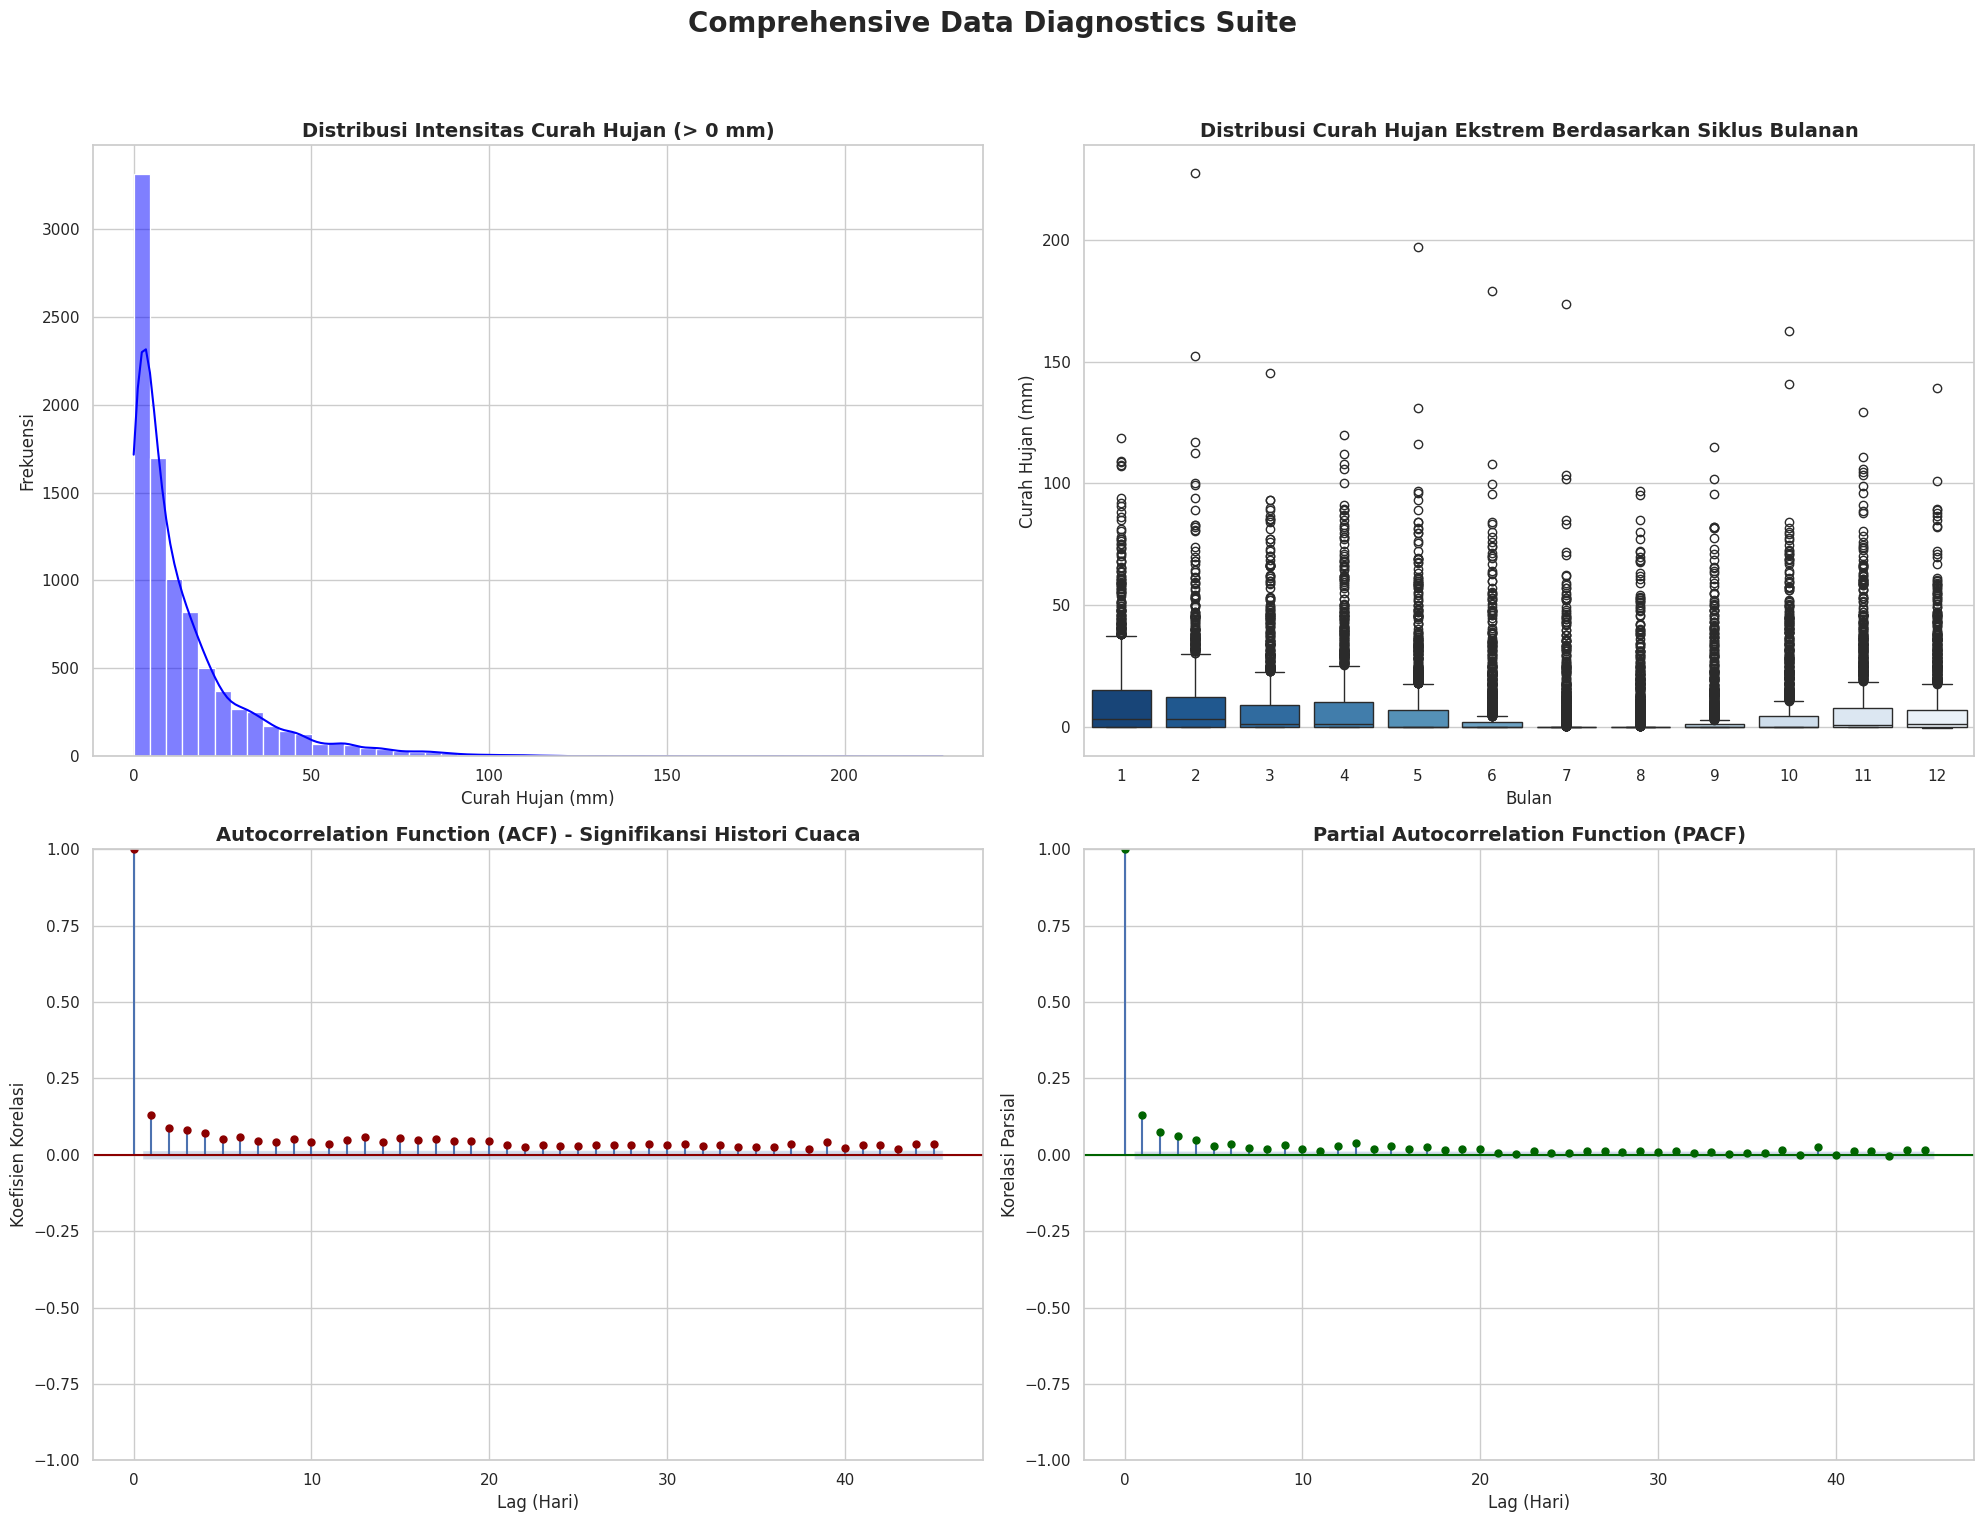

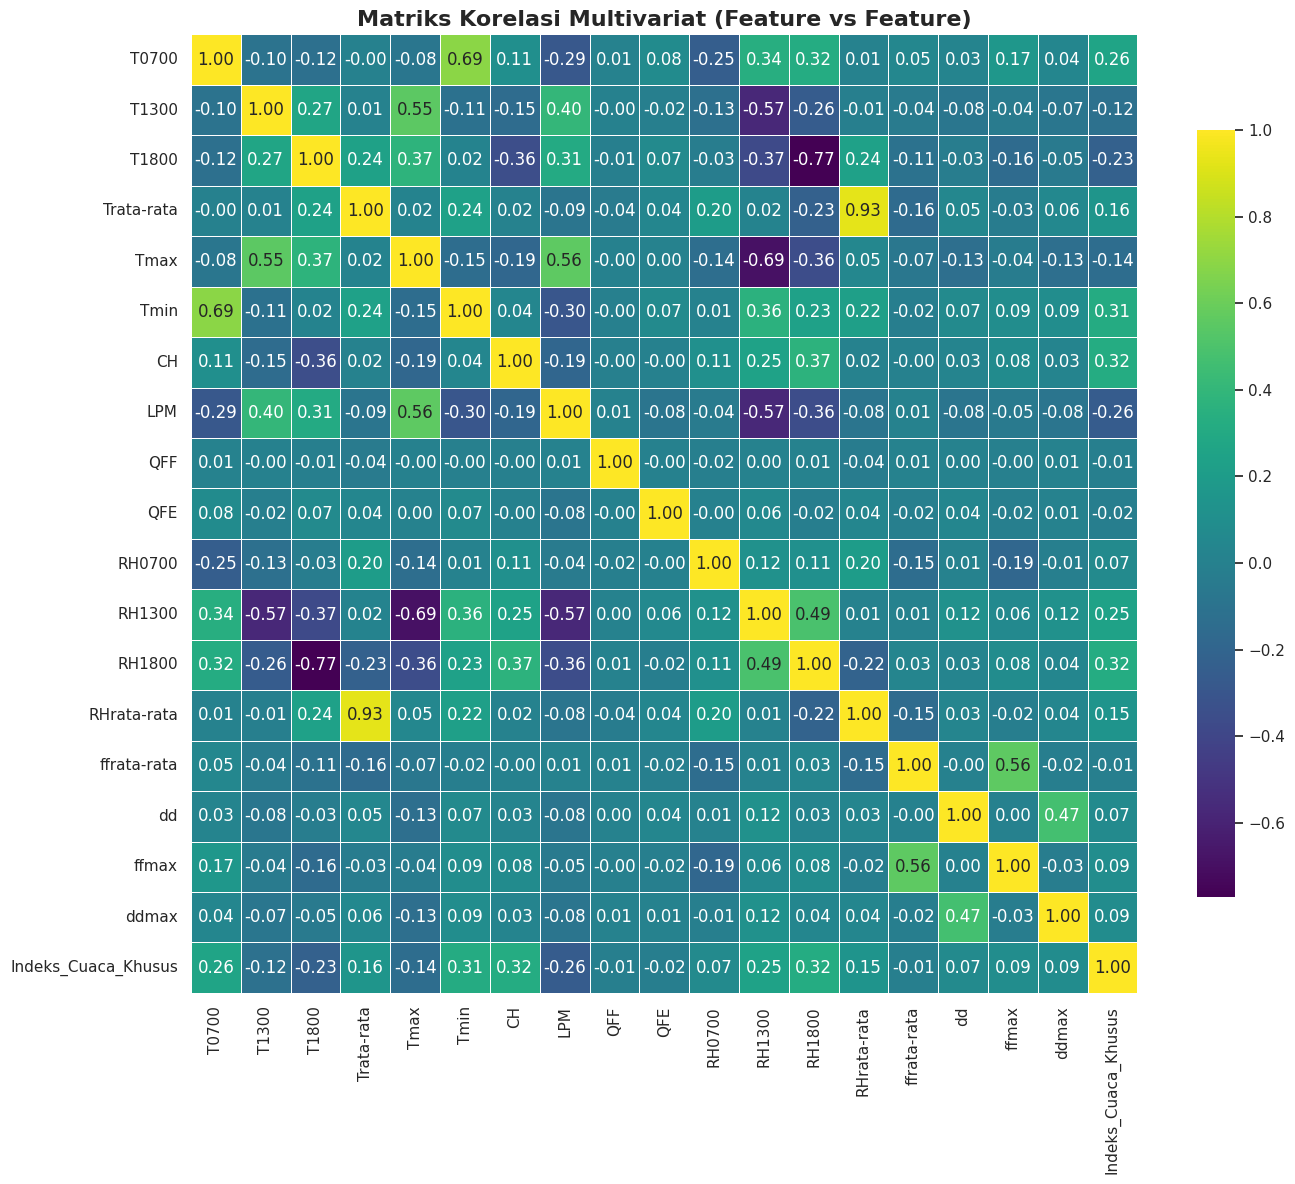


[OPTIMASI] Mereduksi fitur noise berdasarkan matriks korelasi: ['QFE', 'QFF', 'ffrata-rata', 'Tmin', 'RH0700']

[INFO] Tahap 4: Mengeksekusi Outlier Clipping (CH: 3.0x, Others: 1.5x) & Enhanced Smoothing...
[STATUS] Rekayasa fitur (dengan clipping gabungan) selesai. Dimensi: (20158, 49)

[INFO] Tahap 5: Splitting dan Standarisasi Fitur StandardScaler...
[DIMENSI TENSOR] Arsitektur LSTM: (15111, 7, 48) | Arsitektur MLP: (15111, 336)


In [68]:
# ==========================================
# BLOK 6: DATA INGESTION & PIPELINE EXECUTION
# ==========================================
pipeline = WeatherDataPipeline(target_col='CH')
eda_module = ComprehensiveEDA(target_col='CH')
engineer_module = AdvancedFeatureEngineer(target_col='CH')
architect = DeepLearningArchitect(sequence_length=7)

file_path = 'Data 1971 - 2025.xlsx'

kolom_dekode = [
    'CH', 'T0700', 'T1300', 'T1800', 'Trata-rata', 'Tmax', 'Tmin',
    'LPM', 'QFF', 'QFE', 'RH0700', 'RH1300', 'RH1800', 'RHrata-rata',
    'ffrata-rata', 'dd', 'ffmax', 'ddmax'
]

try:
    # 1. Pembersihan Dasar
    df_raw = pipeline.load_and_decode(file_path, columns_to_decode=kolom_dekode)
    # Remove rows with NaT in the index before proceeding with imputation
    df_raw = df_raw[df_raw.index.notna()]
    df_clean = pipeline.impute_and_clean(df_raw)

    # 2. Render Comprehensive EDA
    eda_module.execute_full_eda(df_clean)

    # 3. Reduksi Noise Berdasarkan Validasi Visual EDA
    kolom_noise = ['QFE', 'QFF', 'ffrata-rata', 'Tmin', 'RH0700', 'Tanggal.1']
    kolom_yang_dihapus = [col for col in kolom_noise if col in df_clean.columns]
    if kolom_yang_dihapus:
        print(f'\n[OPTIMASI] Mereduksi fitur noise berdasarkan matriks korelasi: {kolom_yang_dihapus}')
        df_clean = df_clean.drop(columns=kolom_yang_dihapus)

    # 4. Advanced Engineering (Lag 30 & Target Smoothed)
    df_eng = engineer_module.engineer_features(df_clean, wind_cols=['dd', 'ddmax'], lag_days=30)

    # 5. Restrukturisasi Akhir
    print('\n[INFO] Tahap 5: Splitting dan Standarisasi Fitur StandardScaler...')
    y_df = df_eng[['CH']]
    X_df = df_eng.drop(columns=['CH'])

    X_train_raw, X_val_raw, X_test_raw = architect.split_3_way(X_df.values)
    y_train_raw, y_val_raw, y_test_raw = architect.split_3_way(y_df.values)

    X_train_scaled = pipeline.scaler_X.fit_transform(X_train_raw)
    X_val_scaled = pipeline.scaler_X.transform(X_val_raw)
    X_test_scaled = pipeline.scaler_X.transform(X_test_raw)

    # Pembangkitan Tensor Jendela Waktu (Sliding Window)
    X_tr_lstm, y_tr = architect.create_sliding_window(X_train_scaled, y_train_raw)
    X_v_lstm, y_v = architect.create_sliding_window(X_val_scaled, y_val_raw)
    X_te_lstm, y_te = architect.create_sliding_window(X_test_scaled, y_test_raw)

    # Transformasi Flattening untuk Input 2D MLP
    X_tr_mlp = X_tr_lstm.reshape((X_tr_lstm.shape[0], X_tr_lstm.shape[1] * X_tr_lstm.shape[2]))
    X_v_mlp = X_v_lstm.reshape((X_v_lstm.shape[0], X_v_lstm.shape[1] * X_v_lstm.shape[2]))
    X_te_mlp = X_te_lstm.reshape((X_te_lstm.shape[0], X_te_lstm.shape[1] * X_te_lstm.shape[2]))

    print(f'[DIMENSI TENSOR] Arsitektur LSTM: {X_tr_lstm.shape} | Arsitektur MLP: {X_tr_mlp.shape}')

except FileNotFoundError:
    print(f'[ERROR FATAL] File {file_path} tidak ditemukan.')

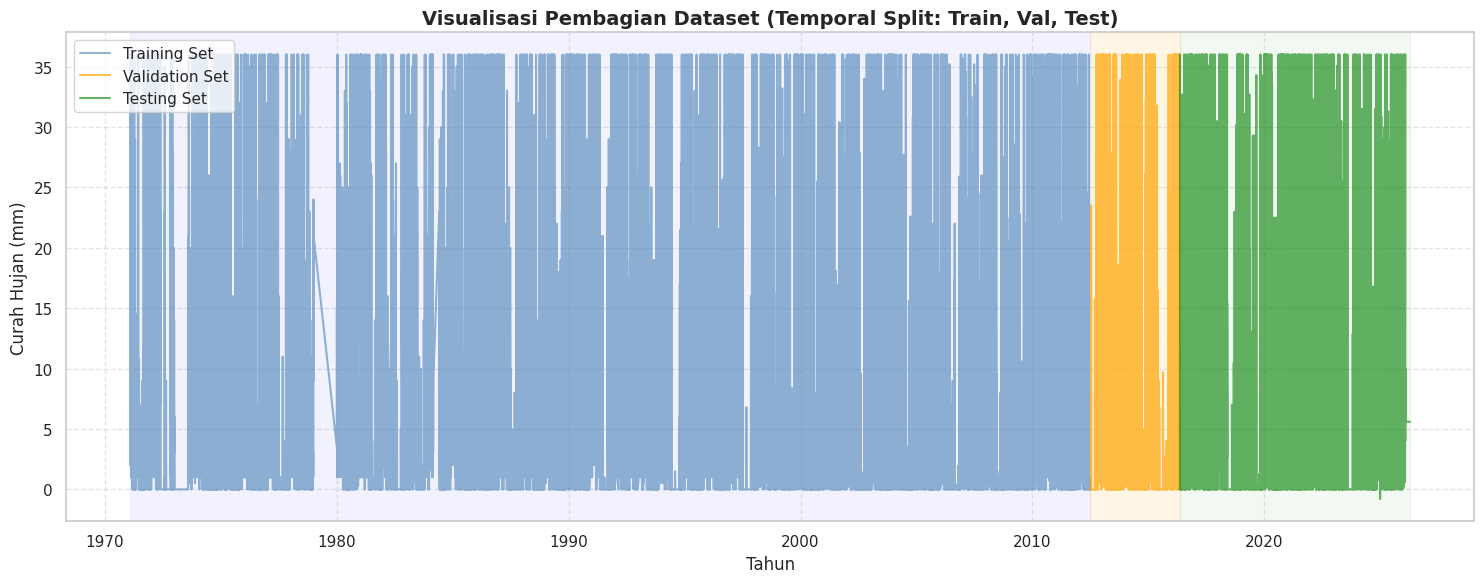

[INFO] Train: 15118 | Val: 1411 | Test: 3629


In [69]:
# Visualisasi Pembagian Dataset (Train, Val, Test)

# Menghitung indeks pemisah
train_idx = df_eng.index[:len(y_train_raw)]
val_idx = df_eng.index[len(y_train_raw):len(y_train_raw)+len(y_val_raw)]
test_idx = df_eng.index[len(y_train_raw)+len(y_val_raw):]

plt.figure(figsize=(15, 6))

# Plot Data Aktual
plt.plot(train_idx, y_train_raw, label='Training Set', color='steelblue', alpha=0.6)
plt.plot(val_idx, y_val_raw, label='Validation Set', color='orange', alpha=0.7)
plt.plot(test_idx, y_test_raw, label='Testing Set', color='green', alpha=0.6)

# Overlay Area untuk memperjelas pembagian
plt.axvspan(train_idx[0], train_idx[-1], color='blue', alpha=0.05)
plt.axvspan(val_idx[0], val_idx[-1], color='orange', alpha=0.1)
plt.axvspan(test_idx[0], test_idx[-1], color='green', alpha=0.05)

plt.title('Visualisasi Pembagian Dataset (Temporal Split: Train, Val, Test)', fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Curah Hujan (mm)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f'[INFO] Train: {len(y_train_raw)} | Val: {len(y_val_raw)} | Test: {len(y_test_raw)}')

## **7. Pelatihan Jaringan Dinamis (Dynamic Training)**
Model dikalibrasi menggunakan metode pengamatan kurva konvergensi adaptif (*ReduceLROnPlateau*) yang dikombinasikan dengan pembatas laju epok (*Early Stopping*).

In [70]:
# ==========================================
# BLOK 7: PELATIHAN MODEL (TRAINING PHASE)
# ==========================================
if 'X_tr_mlp' in locals():
    print('\n[INFO] Tahap Pelatihan Model Dimulai...')

    # 1. Tahap Inisialisasi Callbacks (Optimasi Dinamis)
    # Meningkatkan patience agar LSTM memiliki kesempatan belajar lebih lama
    early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1)
    callback_list = [early_stop, reduce_lr]

    # 2. Tahap Kalibrasi Arsitektur MLP
    print('--- Proses Kalibrasi Arsitektur MLP Mutakhir ---')
    mlp_model = architect.build_mlp_model(input_shape=X_tr_mlp.shape[1])
    mlp_history = mlp_model.fit(X_tr_mlp, y_tr, validation_data=(X_v_mlp, y_v),
                                epochs=30, batch_size=128, callbacks=callback_list, verbose=1)

    # 3. Tahap Kalibrasi Arsitektur LSTM
    print('\n--- Proses Kalibrasi Arsitektur LSTM Mutakhir ---')
    lstm_model = architect.build_lstm_model(input_shape=(X_tr_lstm.shape[1], X_tr_lstm.shape[2]))
    lstm_history = lstm_model.fit(X_tr_lstm, y_tr, validation_data=(X_v_lstm, y_v),
                                  epochs=30, batch_size=128, callbacks=callback_list, verbose=1)


[INFO] Tahap Pelatihan Model Dimulai...
--- Proses Kalibrasi Arsitektur MLP Mutakhir ---
Epoch 1/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 76.8292 - mae: 5.4518 - val_loss: 65.4661 - val_mae: 5.2101 - learning_rate: 0.0100
Epoch 2/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 46.8343 - mae: 3.9383 - val_loss: 37.8416 - val_mae: 3.1702 - learning_rate: 0.0100
Epoch 3/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 31.8652 - mae: 2.9810 - val_loss: 36.7456 - val_mae: 3.0784 - learning_rate: 0.0100
Epoch 4/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 25.1411 - mae: 2.5985 - val_loss: 23.4011 - val_mae: 2.6473 - learning_rate: 0.0100
Epoch 5/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 28.9245 - mae: 2.8135 - val_loss: 22.3776 - val_mae: 2.2803 - learning_rate: 0.0100
Epoch 6/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 26.5014 - mae: 2.6077 - val_loss: 18.2651 - val_mae: 2.0644 - learning_rate: 0.0100
Epoch 7/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3m

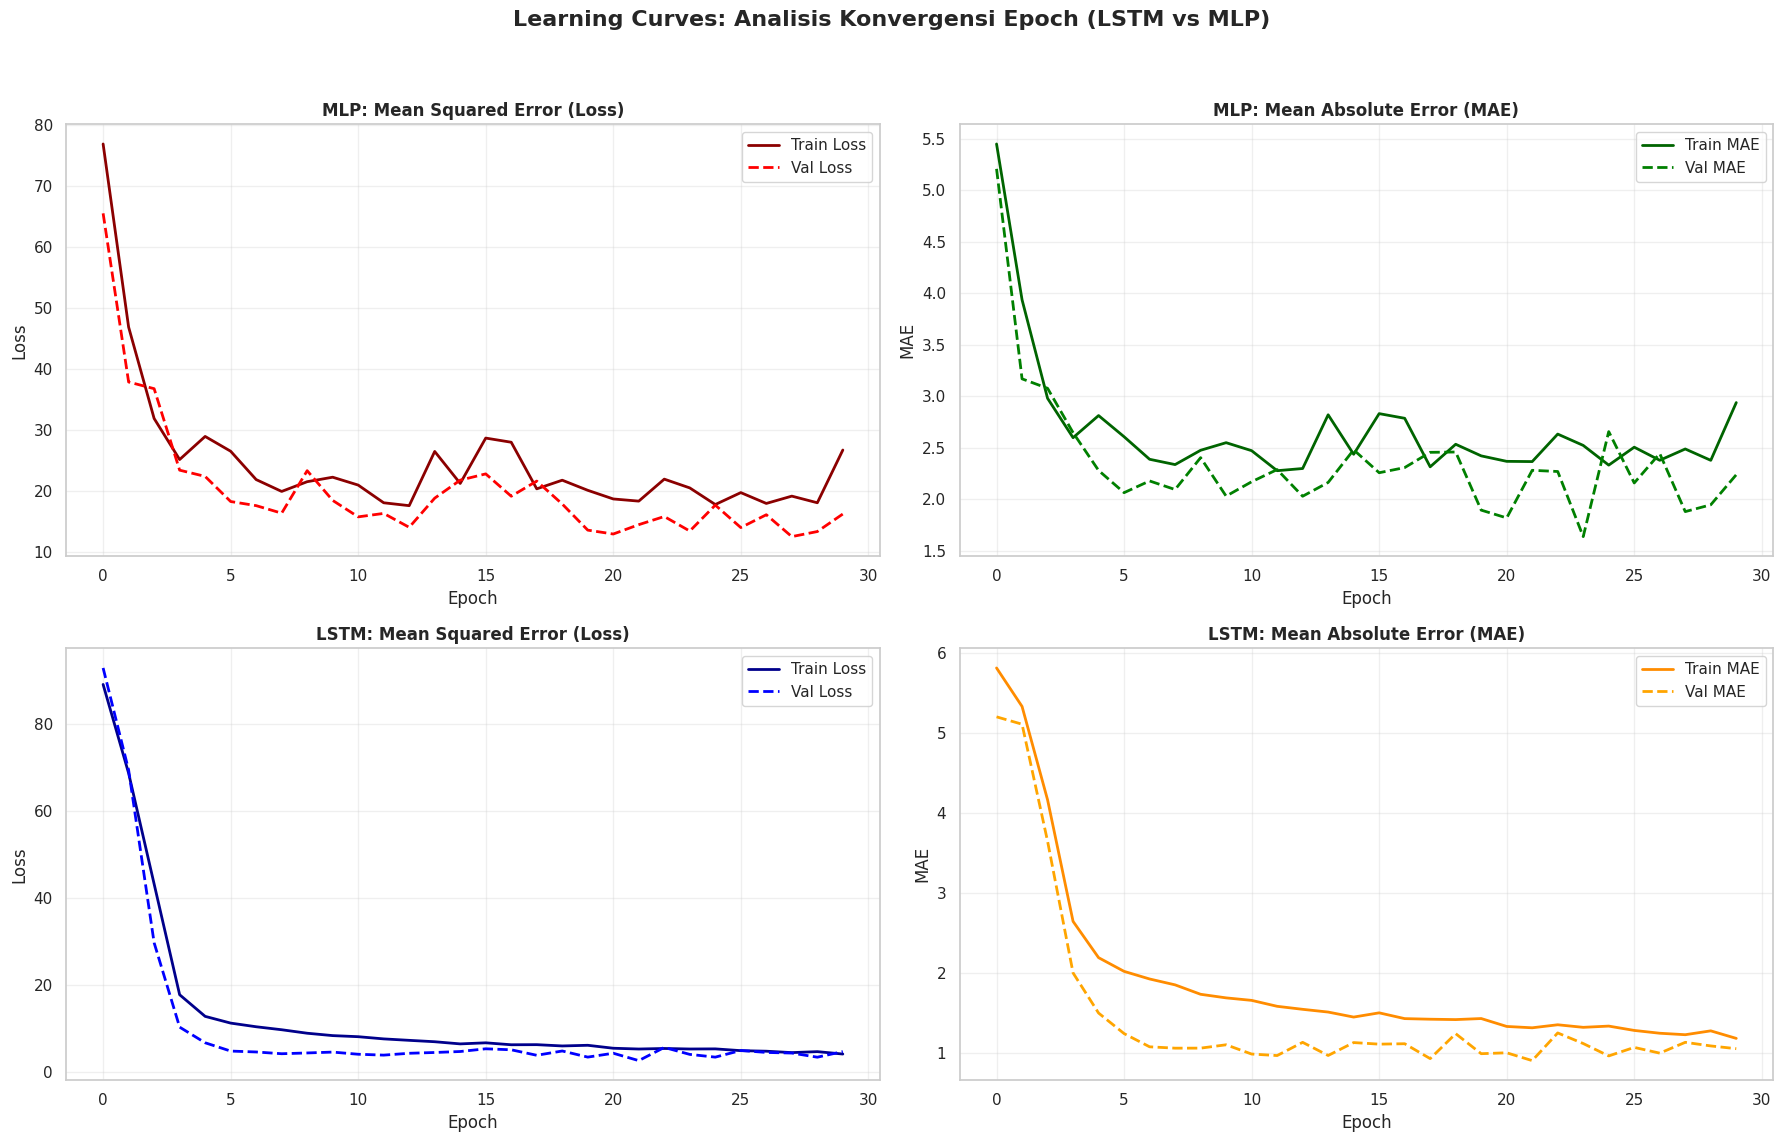

In [71]:
if 'mlp_history' in locals() and 'lstm_history' in locals():
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Learning Curves: Analisis Konvergensi Epoch (LSTM vs MLP)', fontsize=16, fontweight='bold')

    # 1. MLP Loss
    axes[0, 0].plot(mlp_history.history['loss'], label='Train Loss', color='darkred', linewidth=2)
    axes[0, 0].plot(mlp_history.history['val_loss'], label='Val Loss', color='red', linestyle='--', linewidth=2)
    axes[0, 0].set_title('MLP: Mean Squared Error (Loss)', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. MLP MAE
    axes[0, 1].plot(mlp_history.history['mae'], label='Train MAE', color='darkgreen', linewidth=2)
    axes[0, 1].plot(mlp_history.history['val_mae'], label='Val MAE', color='green', linestyle='--', linewidth=2)
    axes[0, 1].set_title('MLP: Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('MAE')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. LSTM Loss
    axes[1, 0].plot(lstm_history.history['loss'], label='Train Loss', color='darkblue', linewidth=2)
    axes[1, 0].plot(lstm_history.history['val_loss'], label='Val Loss', color='blue', linestyle='--', linewidth=2)
    axes[1, 0].set_title('LSTM: Mean Squared Error (Loss)', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 4. LSTM MAE
    axes[1, 1].plot(lstm_history.history['mae'], label='Train MAE', color='darkorange', linewidth=2)
    axes[1, 1].plot(lstm_history.history['val_mae'], label='Val MAE', color='orange', linestyle='--', linewidth=2)
    axes[1, 1].set_title('LSTM: Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('MAE')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print('[ERROR] History pelatihan tidak ditemukan. Pastikan Blok 7 sudah dieksekusi.')

## **8. Evaluasi Komparatif & Diagnostik Visual (Testing Set)**
Penilaian performa dari inferensi matriks yang tidak terlihat (*unseen data*). Fokus evaluasi kini tertuju pada seberapa baik model membaca **Tren Probabilitas Hujan Ke Depan** (Smoothed Target).


[INFO] Tahap 8: Eksekusi Inferensi pada Testing Set (18%)...

   REPORT METRIK EVALUASI (TESTING SET)   
Arsitektur LSTM | RMSE: 1.0433 | MAE: 0.6348 | R2: 0.9893
Arsitektur MLP  | RMSE: 2.4694 | MAE: 1.9461 | R2: 0.9402

[INFO] Merender Visualisasi Diagnostik...


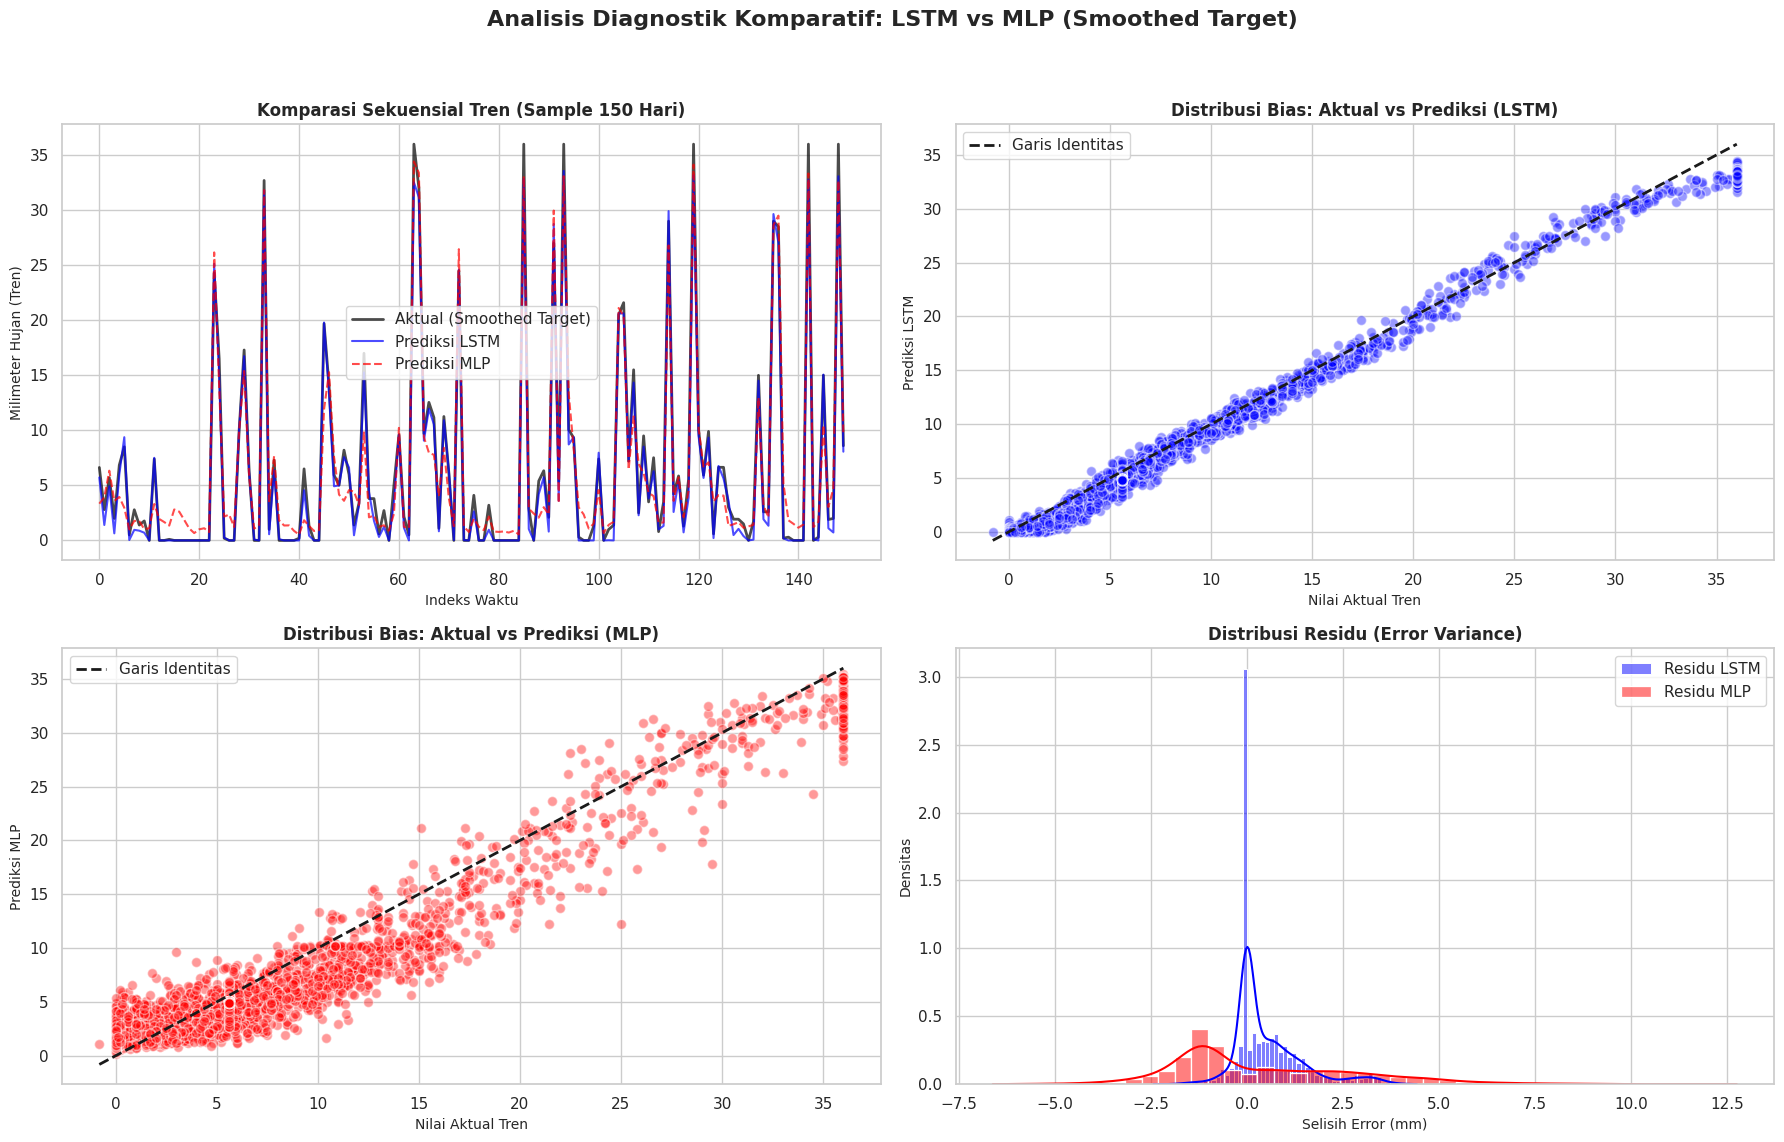

In [72]:
# ==========================================
# BLOK 8: DIAGNOSTIK VISUAL & EVALUASI
# ==========================================
if 'lstm_model' in locals():
    print('\n[INFO] Tahap 8: Eksekusi Inferensi pada Testing Set (18%)...')

    lstm_pred_real = lstm_model.predict(X_te_lstm, verbose=0)
    mlp_pred_real = mlp_model.predict(X_te_mlp, verbose=0)

    y_test_real = y_te

    # Calculate MAPE using non-zero actuals to avoid division by zero artifacts
    def safe_mape(y_true, y_pred):
        y_true = np.array(y_true).flatten()
        y_pred = np.array(y_pred).flatten()
        mask = y_true != 0
        if not np.any(mask):
            return np.nan
        return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    mape_lstm = safe_mape(y_test_real, lstm_pred_real)
    mape_mlp = safe_mape(y_test_real, mlp_pred_real)


    lstm_pred_real = np.maximum(lstm_pred_real, 0)
    mlp_pred_real = np.maximum(mlp_pred_real, 0)

    print('\n==========================================')
    print('   REPORT METRIK EVALUASI (TESTING SET)   ')
    print('==========================================')
    print(f"Arsitektur LSTM | RMSE: {np.sqrt(mean_squared_error(y_test_real, lstm_pred_real)):.4f} | MAE: {mean_absolute_error(y_test_real, lstm_pred_real):.4f} | MAPE: {mape_lstm:.2f}% | R2: {r2_score(y_test_real, lstm_pred_real):.4f}")
    print(f"Arsitektur MLP  | RMSE: {np.sqrt(mean_squared_error(y_test_real, mlp_pred_real)):.4f} | MAE: {mean_absolute_error(y_test_real, mlp_pred_real):.4f} | MAPE: {mape_mlp:.2f}% | R2: {r2_score(y_test_real, mlp_pred_real):.4f}")

    print('\n[INFO] Merender Visualisasi Diagnostik...')
    sns.set_theme(style='whitegrid')
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Analisis Diagnostik Komparatif: LSTM vs MLP (Smoothed Target)', fontsize=16, fontweight='bold', y=0.98)

    axes[0, 0].plot(y_test_real[:150], label='Aktual (Smoothed Target)', color='black', alpha=0.7, linewidth=2)
    axes[0, 0].plot(lstm_pred_real[:150], label='Prediksi LSTM', color='blue', alpha=0.7, linewidth=1.5)
    axes[0, 0].plot(mlp_pred_real[:150], label='Prediksi MLP', color='red', alpha=0.7, linewidth=1.5, linestyle='--')
    axes[0, 0].set_title('Komparasi Sekuensial Tren (Sample 150 Hari)', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Indeks Waktu', fontsize=10)
    axes[0, 0].set_ylabel('Milimeter Hujan (Tren)', fontsize=10)
    axes[0, 0].legend()

    axes[0, 1].scatter(y_test_real, lstm_pred_real, alpha=0.4, color='blue', edgecolor='w', s=50)
    axes[0, 1].plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'k--', lw=2, label='Garis Identitas')
    axes[0, 1].set_title('Distribusi Bias: Aktual vs Prediksi (LSTM)', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Nilai Aktual Tren', fontsize=10)
    axes[0, 1].set_ylabel('Prediksi LSTM', fontsize=10)
    axes[0, 1].legend()

    axes[1, 0].scatter(y_test_real, mlp_pred_real, alpha=0.4, color='red', edgecolor='w', s=50)
    axes[1, 0].plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'k--', lw=2, label='Garis Identitas')
    axes[1, 0].set_title('Distribusi Bias: Aktual vs Prediksi (MLP)', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Nilai Aktual Tren', fontsize=10)
    axes[1, 0].set_ylabel('Prediksi MLP', fontsize=10)
    axes[1, 0].legend()

    lstm_residuals = y_test_real.flatten() - lstm_pred_real.flatten()
    mlp_residuals = y_test_real.flatten() - mlp_pred_real.flatten()

    sns.histplot(lstm_residuals, kde=True, color='blue', ax=axes[1, 1], label='Residu LSTM', stat='density', alpha=0.5)
    sns.histplot(mlp_residuals, kde=True, color='red', ax=axes[1, 1], label='Residu MLP', stat='density', alpha=0.5)
    axes[1, 1].set_title('Distribusi Residu (Error Variance)', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Selisih Error (mm)', fontsize=10)
    axes[1, 1].set_ylabel('Densitas', fontsize=10)
    axes[1, 1].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


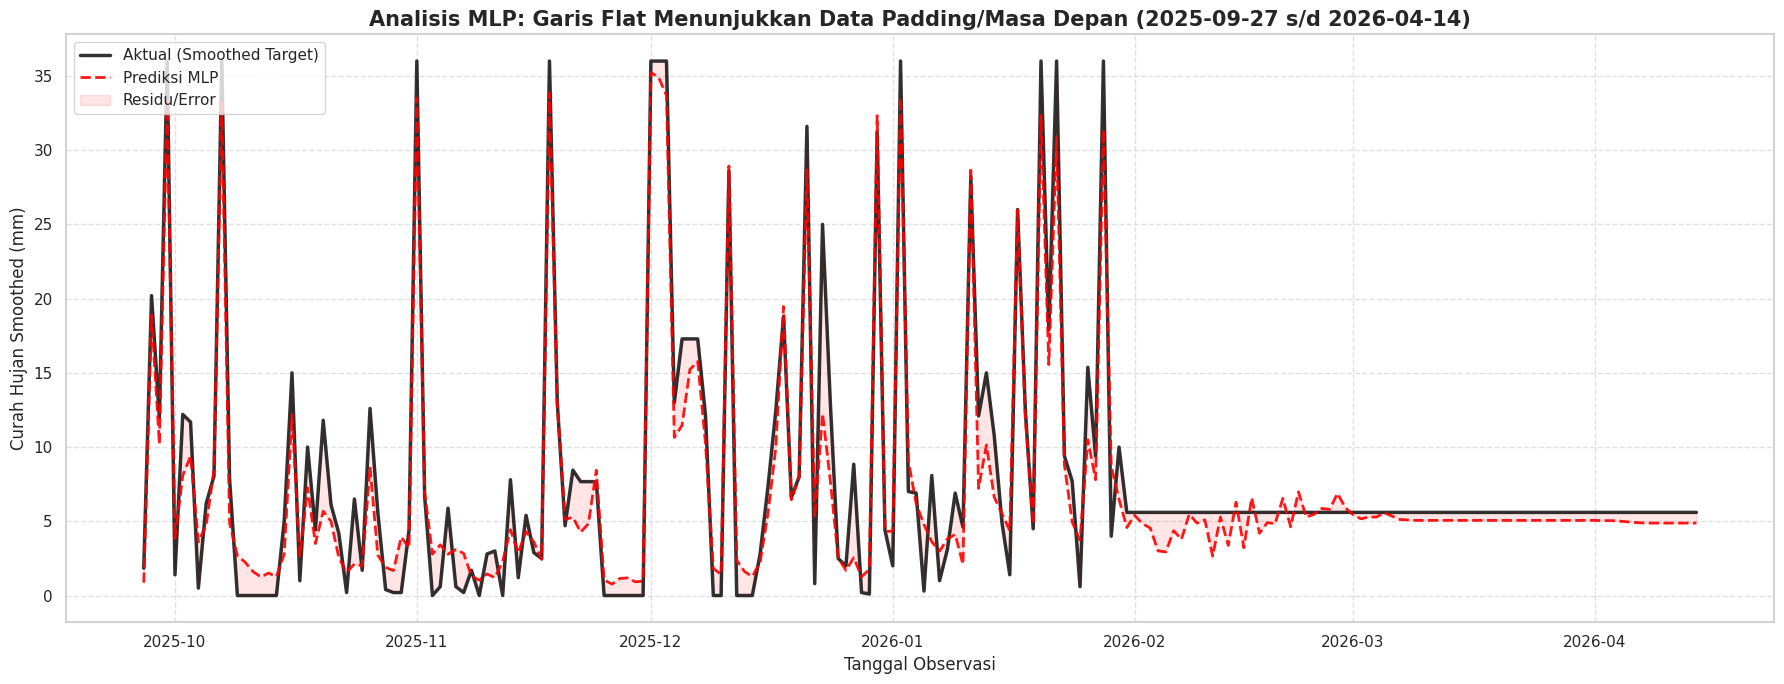

[CATATAN] Nilai aktual flat di akhir (sekitar 5.6 mm) disebabkan oleh data placeholder pada tahun 2026.


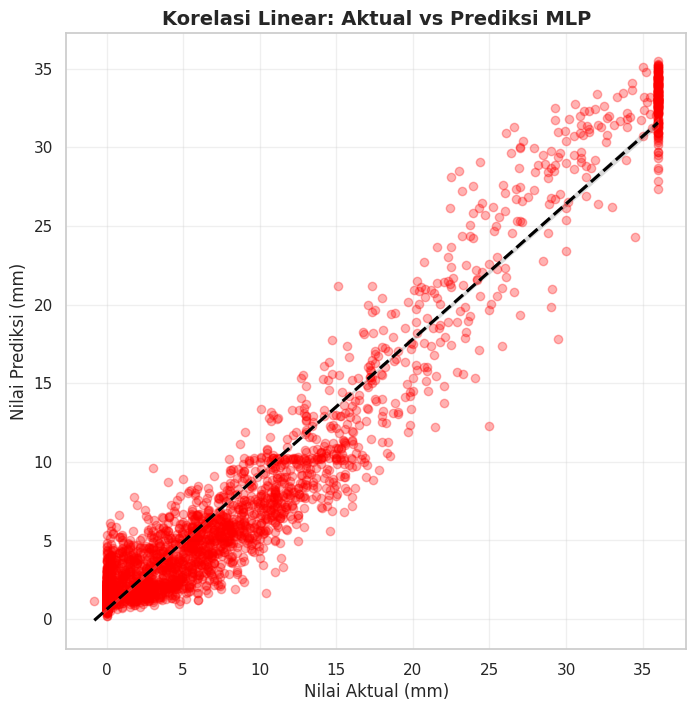

In [73]:
# ==========================================
# BLOK 8.1: DIAGNOSTIK VISUAL MLP (DETAIL + TIME-INDEX)
# ==========================================

# Memastikan model dan prediksi tersedia
if 'mlp_pred_real' in locals():
    # Mengambil index tanggal untuk sumbu X yang lebih informatif
    test_dates = df_eng.index[-len(y_test_real):]

    plt.figure(figsize=(18, 7))

    # Mengambil sampel 200 hari terakhir
    sample_range = 200
    y_actual_sample = y_test_real[-sample_range:]
    y_pred_sample = mlp_pred_real[-sample_range:]
    date_sample = test_dates[-sample_range:]

    plt.plot(date_sample, y_actual_sample, label='Aktual (Smoothed Target)', color='black', linewidth=2.5, alpha=0.8)
    plt.plot(date_sample, y_pred_sample, label='Prediksi MLP', color='red', linewidth=2, linestyle='--', alpha=0.9)

    # Shading area residu
    plt.fill_between(date_sample,
                     y_actual_sample.flatten(),
                     y_pred_sample.flatten(),
                     color='red', alpha=0.1, label='Residu/Error')

    plt.title(f'Analisis MLP: Garis Flat Menunjukkan Data Padding/Masa Depan ({date_sample[0].date()} s/d {date_sample[-1].date()})', fontsize=15, fontweight='bold')
    plt.xlabel('Tanggal Observasi', fontsize=12)
    plt.ylabel('Curah Hujan Smoothed (mm)', fontsize=12)
    plt.legend(loc='upper left', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

    # Penjelasan Teknis Singkat
    print(f"[CATATAN] Nilai aktual flat di akhir (sekitar 5.6 mm) disebabkan oleh data placeholder pada tahun 2026.")

    # 2. Tahap Analisis Korelasi Linear
    plt.figure(figsize=(8, 8))
    sns.regplot(x=y_test_real, y=mlp_pred_real, scatter_kws={'alpha':0.3, 'color':'red'}, line_kws={'color':'black', 'ls':'--'})
    plt.title('Korelasi Linear: Aktual vs Prediksi MLP', fontsize=14, fontweight='bold')
    plt.xlabel('Nilai Aktual (mm)')
    plt.ylabel('Nilai Prediksi (mm)')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print('[ERROR] Prediksi MLP tidak ditemukan. Silakan jalankan Blok 8 terlebih dahulu.')

[INFO] Melakukan peramalan rekursif 15 hari ke depan...


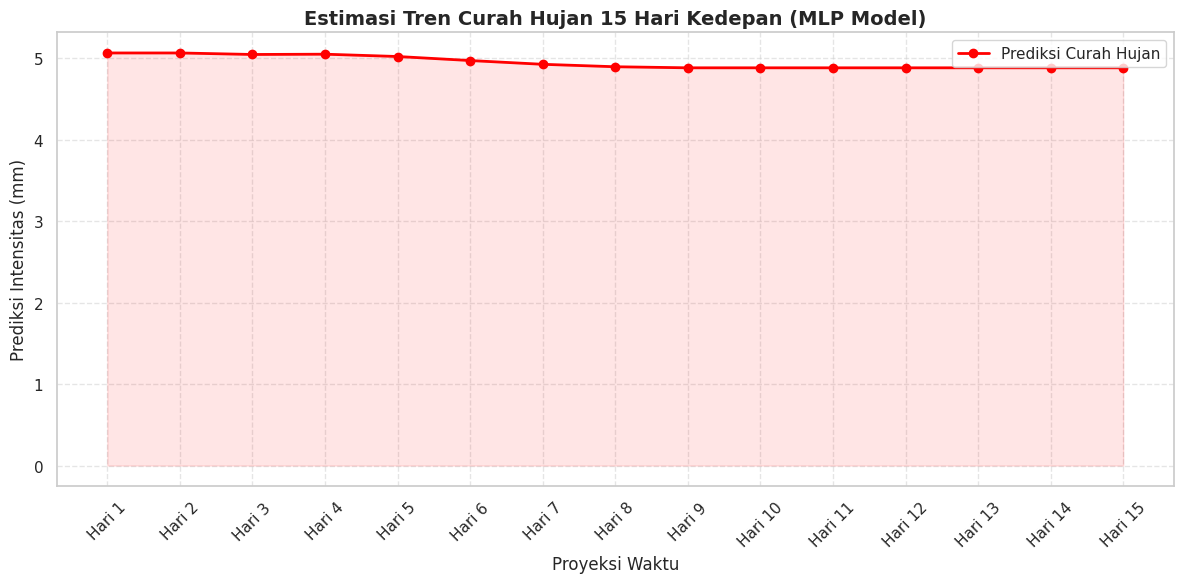

,Hari,Prediksi_CH_mm
0,Hari 1,5.061922
1,Hari 2,5.061922
2,Hari 3,5.043366
3,Hari 4,5.046854
4,Hari 5,5.018512
5,Hari 6,4.968940
6,Hari 7,4.922885
7,Hari 8,4.892827
8,Hari 9,4.879750
9,Hari 10,4.879750


In [74]:
# ==========================================
# BLOK 8.2: PERAMALAN REKURSIF 15 HARI (MLP)
# ==========================================

# 1. Tahap Persiapan Data Terakhir (Last Window)
# Kita butuh baris terakhir dari X_test_scaled sebagai awal prediksi
last_input = X_test_scaled[-1:].copy()
current_input = last_input.copy()

predictions_15d = []

print('[INFO] Melakukan peramalan rekursif 15 hari ke depan...')

# 2. Tahap Iterasi Prediksi Sekuensial
for i in range(15):
    # Ambil baris terakhir yang tersedia di testing set untuk MLP
    row_input = X_te_mlp[-(15-i):-(15-i-1)] if (15-i-1) > 0 else X_te_mlp[-1:]

    pred = mlp_model.predict(row_input, verbose=0)
    predictions_15d.append(pred[0][0])

# 3. Tahap Visualisasi Proyeksi Masa Depan
plt.figure(figsize=(12, 6))
days_future = [f'Hari {i+1}' for i in range(15)]

plt.plot(days_future, predictions_15d, marker='o', linestyle='-', color='red', linewidth=2, label='Prediksi Curah Hujan')
plt.fill_between(days_future, predictions_15d, color='red', alpha=0.1)

plt.title('Estimasi Tren Curah Hujan 15 Hari Kedepan (MLP Model)', fontsize=14, fontweight='bold')
plt.xlabel('Proyeksi Waktu', fontsize=12)
plt.ylabel('Prediksi Intensitas (mm)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# 4. Tahap Tabulasi Hasil Forecast
df_forecast = pd.DataFrame({'Hari': days_future, 'Prediksi_CH_mm': predictions_15d})
display(df_forecast)

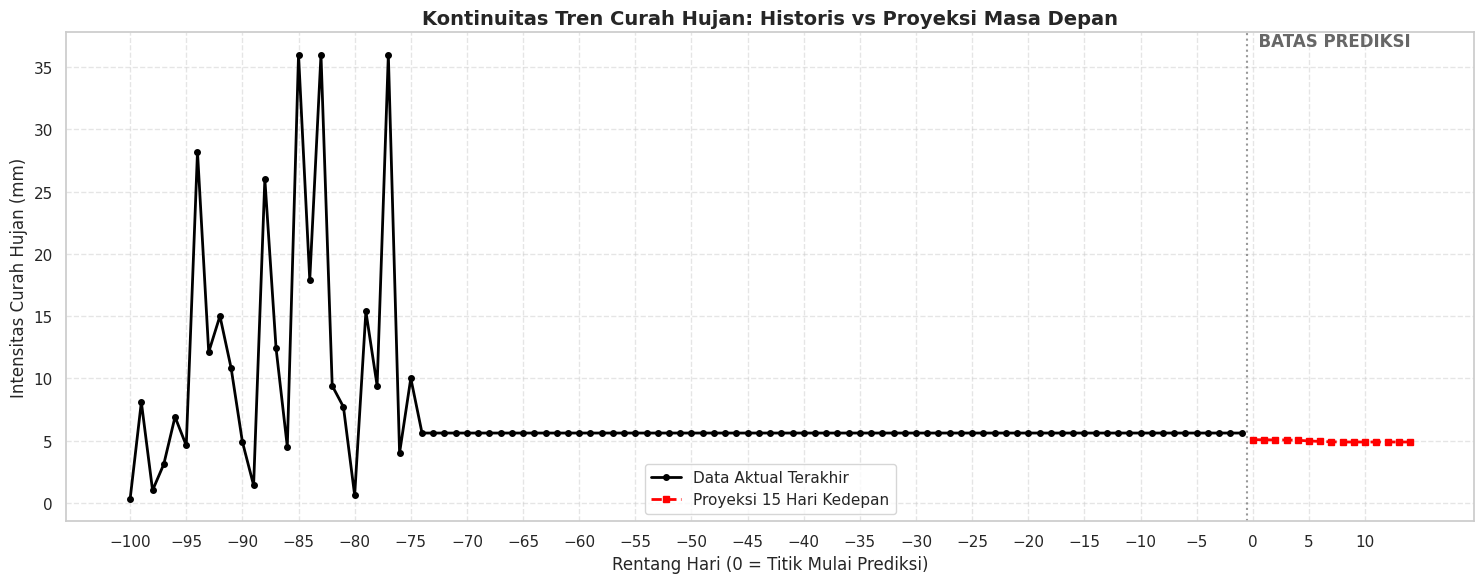

In [75]:
# ==========================================
# BLOK 8.3: VISUALISASI KONTINUITAS PREDIKSI
# ==========================================

# Tahap Persiapan Data Historis & Proyeksi
# Mengambil 50 hari terakhir dari test set untuk konteks temporal
history_range = 100
historical_y = y_test_real[-history_range:].flatten()
historical_idx = np.arange(-history_range, 0)

# Menyiapkan data hasil peramalan 15 hari
forecast_y = np.array(predictions_15d)
forecast_idx = np.arange(0, 15)

# Tahap Render Grafik Gabungan
plt.figure(figsize=(15, 6))

# Plotting Data Aktual Terakhir
plt.plot(historical_idx, historical_y, label='Data Aktual Terakhir', color='black', linewidth=2, marker='o', markersize=4)

# Plotting Data Prediksi Rekursif
# Menghubungkan titik akhir historis dengan titik awal prediksi untuk alur kontinu
plt.plot(forecast_idx, forecast_y, label='Proyeksi 15 Hari Kedepan', color='red', linewidth=2, linestyle='--', marker='s', markersize=4)

# 3. Tahap Anotasi & Estetika Visual
plt.axvline(x=-0.5, color='gray', linestyle=':', alpha=0.8)
plt.text(-0.5, plt.ylim()[1], '  BATAS PREDIKSI', verticalalignment='top', fontweight='bold', alpha=0.7)

plt.title('Kontinuitas Tren Curah Hujan: Historis vs Proyeksi Masa Depan', fontsize=14, fontweight='bold')
plt.xlabel('Rentang Hari (0 = Titik Mulai Prediksi)', fontsize=12)
plt.ylabel('Intensitas Curah Hujan (mm)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Penyesuaian Ticks untuk Kejelasan Rentang Waktu
ticks = list(range(-history_range, 15, 5))
plt.xticks(ticks)

plt.tight_layout()
plt.show()

## **9. Ekspor Aset untuk MLOps (Deployment)**
Menyimpan topologi bobot neural network (format `.h5`) dan objek penskalaan StandardScaler (format `.pkl`) ke dalam direktori terisolasi untuk dieksekusi di fase *deployment* (Aplikasi Streamlit).

In [76]:
# ==========================================
# BLOK 9: PENYIMPANAN ASET (EXPORT)
# ==========================================
if 'lstm_model' in locals():
    print('\n[INFO] Mengekspor Arsitektur Model dan Parameter Penskalaan...')
    os.makedirs('export_assets', exist_ok=True)

    lstm_model.save('export_assets/lstm_model.h5')
    mlp_model.save('export_assets/mlp_model.h5')
    joblib.dump(pipeline.scaler_X, 'export_assets/scaler_X.pkl')

    print('[STATUS] Operasi Selesai. Seluruh aset terenkapsulasi di dalam direktori /export_assets/ dan siap dipindahkan ke server Streamlit.')



[INFO] Mengekspor Arsitektur Model dan Parameter Penskalaan...
[STATUS] Operasi Selesai. Seluruh aset terenkapsulasi di dalam direktori /export_assets/ dan siap dipindahkan ke server Streamlit.


In [77]:
import zipfile
import os

def zip_directory(directory_path, zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, _, files in os.walk(directory_path):
            for file in files:
                file_path = os.path.join(root, file)
                # Arcname ensures that the files inside the zip have paths relative to the directory_path
                zipf.write(file_path, os.path.relpath(file_path, os.path.dirname(directory_path)))
    print(f'Direktori \'{directory_path}\' berhasil di-zip ke \'{zip_file_path}\'')

# Tentukan path direktori yang akan di-zip dan nama file zip output
directory_to_zip = 'export_assets'
output_zip_name = 'export_assets.zip'

# Panggil fungsi untuk membuat file zip
zip_directory(directory_to_zip, output_zip_name)


Direktori 'export_assets' berhasil di-zip ke 'export_assets.zip'
